# Cryptocurrency Volatility Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset.csv')

In [5]:
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [6]:
df.columns

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'marketCap',
       'timestamp', 'crypto_name', 'date'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [9]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df = df.sort_values(by='date')

In [12]:
df['volatility'] = (df['high'] - df['low']) / df['close']

In [13]:
df[['high', 'low', 'close', 'volatility']].head()

,high,low,close,volatility
0,118.800003,107.142998,115.910004,0.100569
1,3.692460,3.346060,3.590890,0.096466
2,124.663002,106.639999,112.300003,0.160490
3,3.781020,3.116020,3.371250,0.197256
4,113.444000,97.699997,111.500000,0.141202


In [15]:
df['daily_return'] = (df['close'] - df['open']) / df['open']

df['ma_7'] = df['close'].rolling(window=7).mean()

df['rolling_volatility'] = df['close'].rolling(window=7).std()

df['liquidity_ratio'] = df['volume'] / df['marketCap']

In [16]:
df.dropna(inplace=True)

In [17]:
df.head()

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,volatility,daily_return,ma_7,rolling_volatility,liquidity_ratio
6,3.283620,3.491120,3.283620,3.409240,0.0,5.950822e+07,2013-05-08T23:59:59.999Z,Litecoin,2013-05-08,0.060864,0.038257,50.487732,58.711983,0.0
7,109.599998,115.779999,109.599998,113.566002,0.0,1.264049e+09,2013-05-08T23:59:59.999Z,Bitcoin,2013-05-08,0.054418,0.036186,50.152875,58.281774,0.0
9,113.199997,113.459999,109.260002,112.669998,0.0,1.254535e+09,2013-05-09T23:59:59.999Z,Bitcoin,2013-05-09,0.037277,-0.004682,65.735605,58.339828,0.0
8,3.399400,3.441690,3.294850,3.416150,0.0,5.975557e+07,2013-05-09T23:59:59.999Z,Litecoin,2013-05-09,0.042984,0.004927,50.180769,58.370960,0.0
10,112.799004,122.000000,111.551003,117.199997,0.0,1.305479e+09,2013-05-10T23:59:59.999Z,Bitcoin,2013-05-10,0.089155,0.039016,66.442018,59.009127,0.0


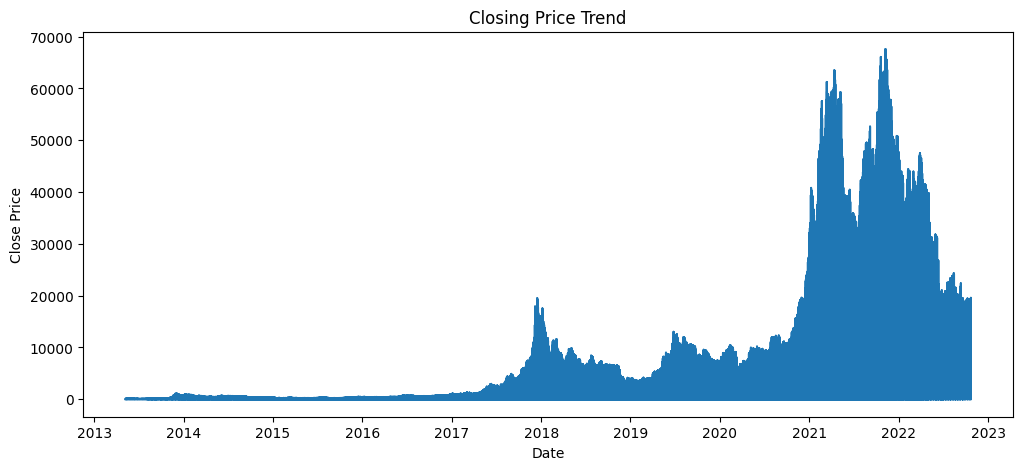

In [18]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['close'])
plt.title('Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

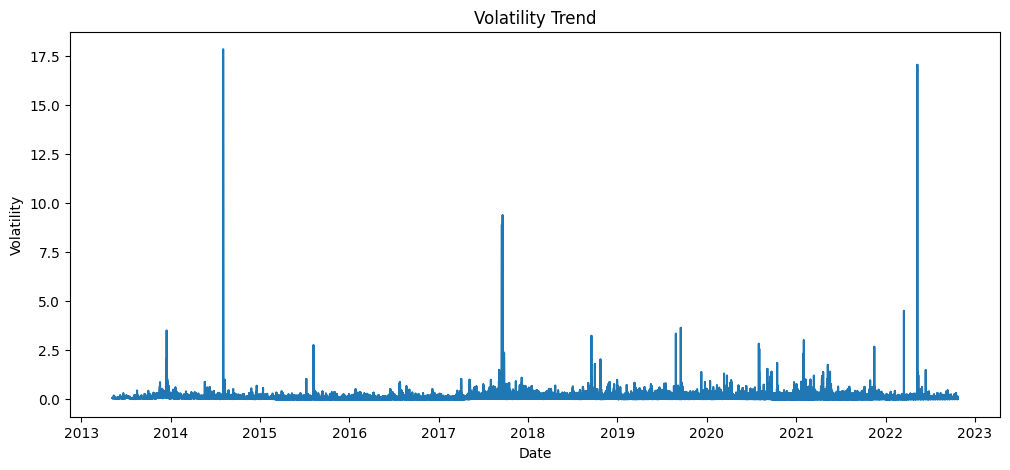

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['volatility'])
plt.title('Volatility Trend')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

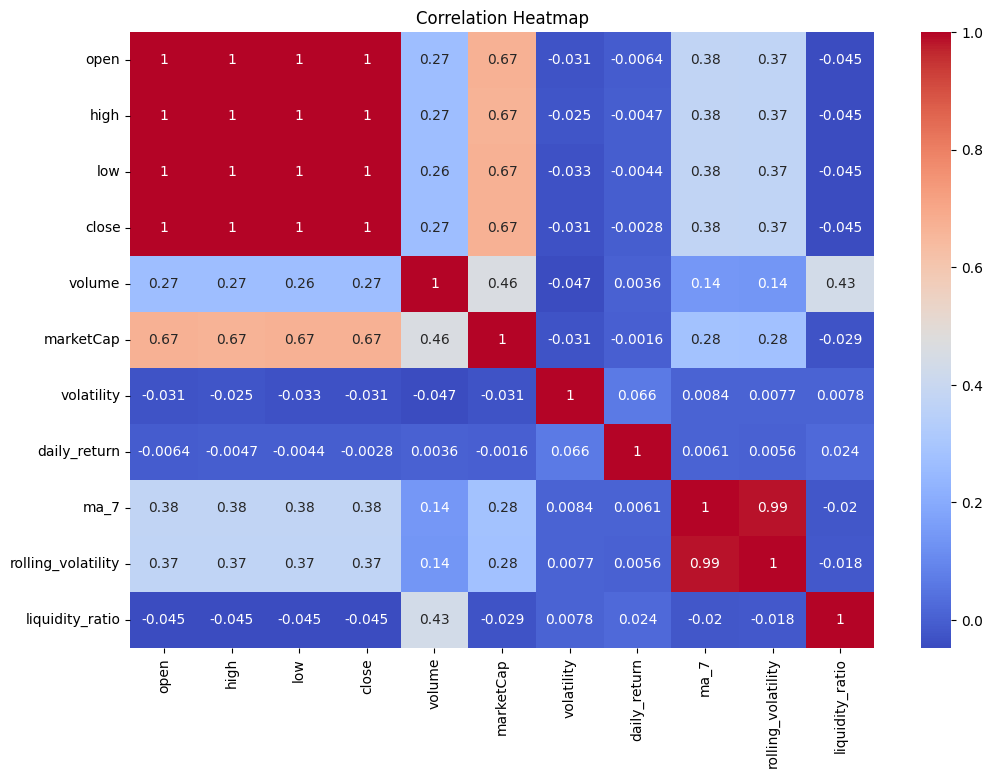

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [24]:
np.isinf(X).sum()

,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
daily_return,1
ma_7,0
rolling_volatility,0
liquidity_ratio,2416


In [25]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [26]:
features = [
    'open',
    'high',
    'low',
    'close',
    'volume',
    'marketCap',
    'daily_return',
    'ma_7',
    'rolling_volatility',
    'liquidity_ratio'
]

X = df[features]
y = df['volatility']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 0.023445310154491146
RMSE : 0.04591991959243636
R2 Score : 0.689531132228969


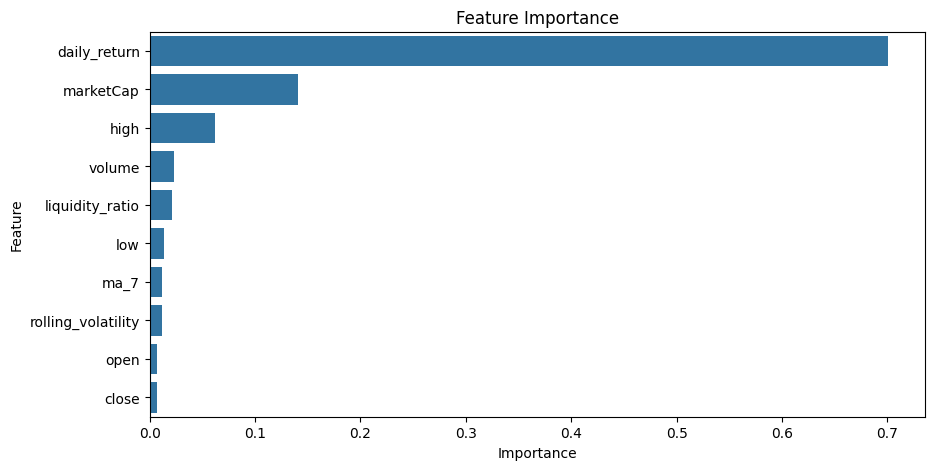

In [31]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')
plt.show()

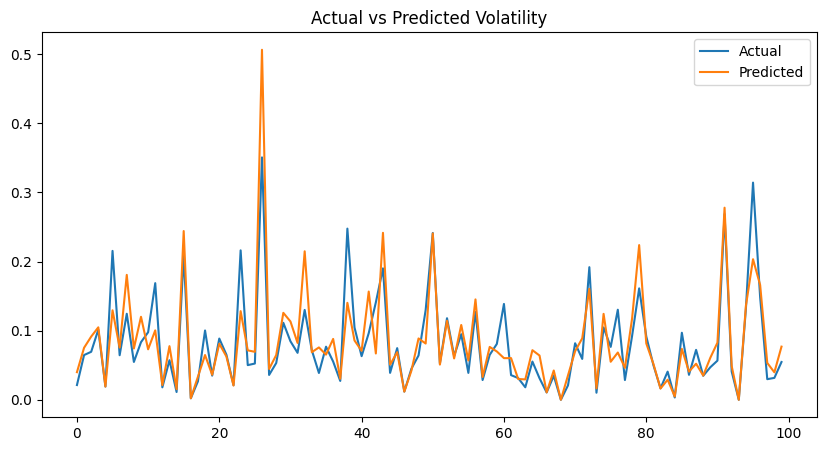

In [32]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual')

plt.plot(y_pred[:100], label='Predicted')

plt.legend()

plt.title('Actual vs Predicted Volatility')

plt.show()

In [33]:
import joblib

joblib.dump(model, 'crypto_volatility_model.pkl')

['crypto_volatility_model.pkl']

In [34]:
from google.colab import files

files.download('crypto_volatility_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
df.to_csv('cleaned_crypto_data.csv', index=False)

files.download('cleaned_crypto_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>